# Traffic Demand Prediction — Exploratory Data Analysis

Regression target `demand` in (0,1]; score = `max(0, 100*R2)`.

**Structural spine (verified):** train = day 48 (full, 96 slots) + day 49 (9 night slots); test = day 49 daytime (02:15-13:45, 47 slots). The test is the **immediate forward continuation** of the city for **mostly-seen** geohashes (1180/1190 seen). So this is a spatio-temporal forecast.

In [1]:
import sys; sys.path.append('../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import features as F, pipeline as P
plt.rcParams['figure.dpi']=110
train, test = F.load_raw()
train = F.add_base_features(train); test = F.add_base_features(test)
print('train', train.shape, '| test', test.shape)
train[['geohash','day','timestamp','tmin','demand','RoadType','NumberofLanes']].head()

train (77299, 31) | test (41778, 30)


,geohash,day,timestamp,tmin,demand,RoadType,NumberofLanes
0,qp02z1,48,0:0,0,0.048804,NaN,1
1,qp02zt,48,0:0,0,0.118507,Residential,3
2,qp08bj,48,0:0,0,0.027132,Residential,1
3,qp08gt,48,0:0,0,0.003272,Residential,1
4,qp02zq,48,0:0,0,0.010819,Residential,1


## 1. Target distribution (raw + log)

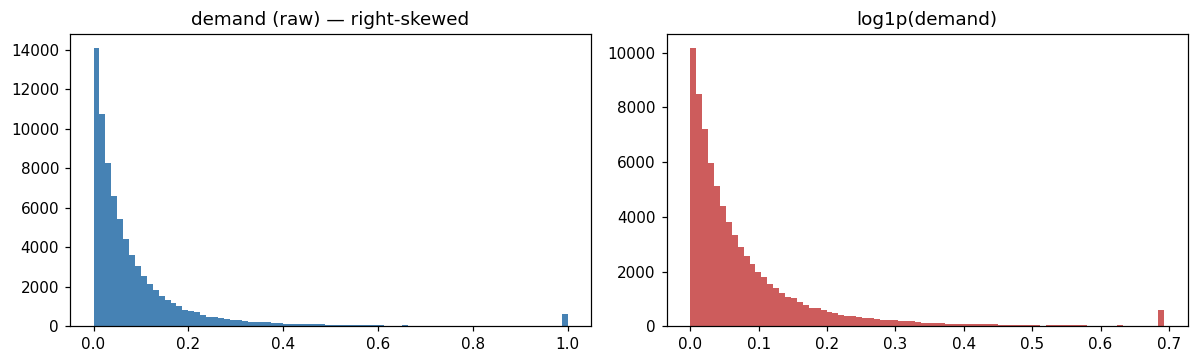

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [2]:
fig,ax=plt.subplots(1,2,figsize=(11,3.4))
ax[0].hist(train['demand'],bins=80,color='steelblue'); ax[0].set_title('demand (raw) — right-skewed')
ax[1].hist(np.log1p(train['demand']),bins=80,color='indianred'); ax[1].set_title('log1p(demand)')
plt.tight_layout(); plt.show()
print(train['demand'].describe())

## 2. Time-of-day cycle (peak ~11-13h, trough ~19h)

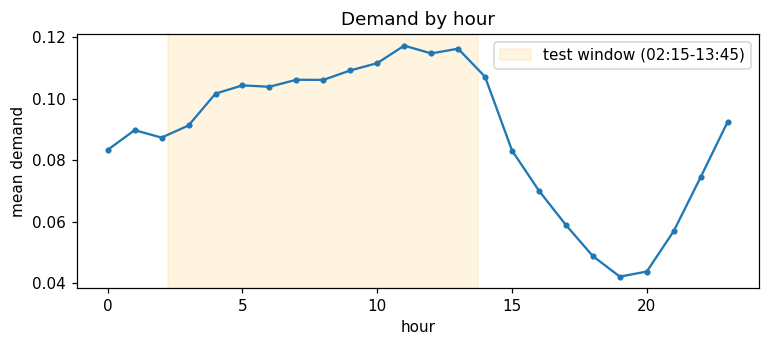

In [3]:
by_hr = train.groupby('hour')['demand'].mean()
plt.figure(figsize=(8,3)); plt.plot(by_hr.index, by_hr.values,'-o',ms=3)
plt.axvspan(2.25,13.75,alpha=0.12,color='orange',label='test window (02:15-13:45)')
plt.xlabel('hour'); plt.ylabel('mean demand'); plt.legend(); plt.title('Demand by hour'); plt.show()

## 3. RoadType dominates; lanes help; weather/temp do not

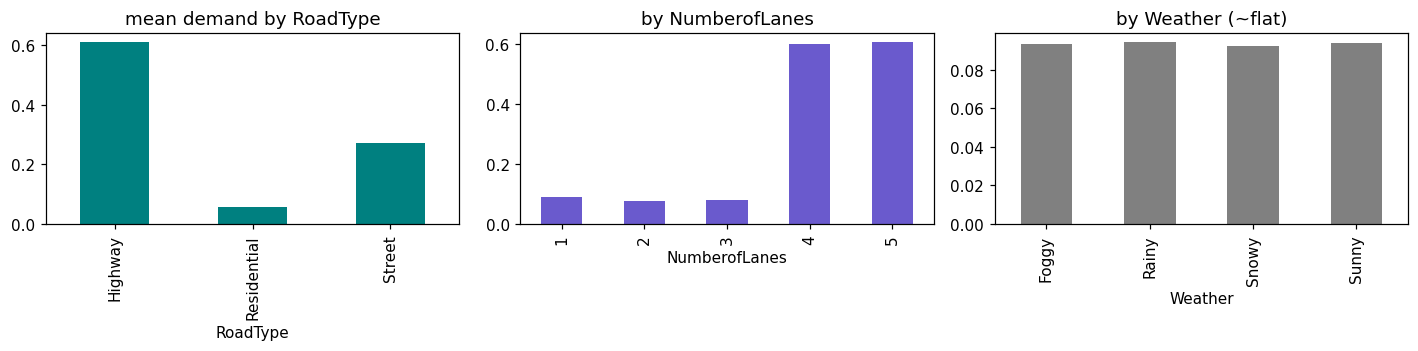

corr(demand,Temperature)=0.0031  corr(demand,NumberofLanes)=0.2141


In [4]:
fig,ax=plt.subplots(1,3,figsize=(13,3.3))
train.groupby('RoadType')['demand'].mean().plot.bar(ax=ax[0],color='teal'); ax[0].set_title('mean demand by RoadType')
train.groupby('NumberofLanes')['demand'].mean().plot.bar(ax=ax[1],color='slateblue'); ax[1].set_title('by NumberofLanes')
train.groupby('Weather')['demand'].mean().plot.bar(ax=ax[2],color='gray'); ax[2].set_title('by Weather (~flat)')
plt.tight_layout(); plt.show()
print('corr(demand,Temperature)=%.4f  corr(demand,NumberofLanes)=%.4f'%(
  train['demand'].corr(train['Temperature']), train['demand'].corr(train['NumberofLanes'])))

## 4. Spatial structure (decoded geohash) + region clusters

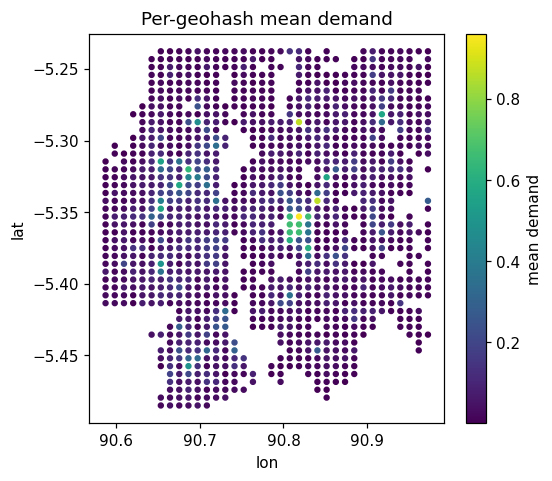

prefix-4 regions: 6 | prefix-5 regions: 56 | geohashes: 1249


In [5]:
gm = train.groupby('geohash').agg(lat=('lat','first'),lon=('lon','first'),demand=('demand','mean'))
plt.figure(figsize=(5.2,4.6)); s=plt.scatter(gm['lon'],gm['lat'],c=gm['demand'],s=10,cmap='viridis')
plt.colorbar(s,label='mean demand'); plt.xlabel('lon'); plt.ylabel('lat'); plt.title('Per-geohash mean demand'); plt.show()
print('prefix-4 regions:', train['p4'].nunique(), '| prefix-5 regions:', train['p5'].nunique(),
      '| geohashes:', train['geohash'].nunique())

## 5. Cross-day drift — why an honest R2=1.0 is unreachable
Per-(geohash, time-of-day) demand on day 48 vs day 49. If demand repeated exactly, all points would lie on y=x. They scatter (Pearson ~0.79), so the public 100s indicate a leaked/recoverable target, not honest skill.

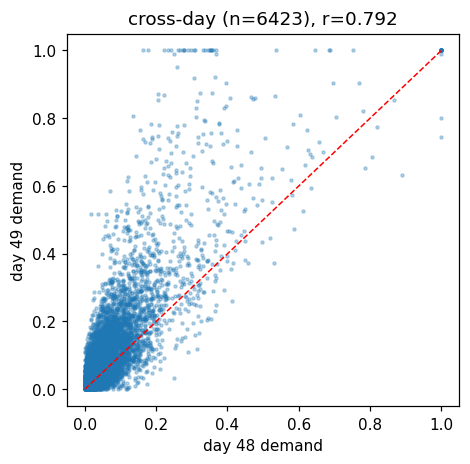

affine day49 ~ 0.032 + 1.255*day48


In [6]:
piv = train.pivot_table(index=['geohash','tmin'],columns='day',values='demand')
piv = piv.dropna()
plt.figure(figsize=(4.6,4.4)); plt.scatter(piv[48],piv[49],s=4,alpha=0.3)
lim=[0,piv.values.max()]; plt.plot(lim,lim,'r--',lw=1)
plt.xlabel('day 48 demand'); plt.ylabel('day 49 demand')
plt.title('cross-day (n=%d), r=%.3f'%(len(piv),piv[48].corr(piv[49]))); plt.show()
from numpy import polyfit
b,a=polyfit(piv[48],piv[49],1); print('affine day49 ~ %.3f + %.3f*day48'%(a,b))

## 6. Generalization vs memorization (the modeling thesis)
Forward (day48->day49) R2 of single predictors. RoadType (stable structure) transfers far better than fine geohash/slot memorization, which is dragged down by day-to-day drift.

In [7]:
import cv
tr = P.prepare(F.load_raw()[0])
for name,val in cv.baseline_ladder(tr):
    print(f'  {name:20s} forward R2 = {val:.4f}')

  global_mean          forward R2 = -0.0076
  RoadType_mean        forward R2 = 0.7554
  per_geohash_mean     forward R2 = 0.6560
  d48_slot_raw         forward R2 = 0.5223
  d48_slot_affine      forward R2 = 0.6341


## 7. Missingness (small, balanced across train/test)

In [8]:
miss = pd.DataFrame({'train_%':(train.isna().mean()*100).round(2)})
miss['test_%']=(test.reindex(columns=train.columns).isna().mean()*100).round(2)
miss.loc[['RoadType','Temperature','Weather']]

,train_%,test_%
RoadType,0.78,0.78
Temperature,3.23,3.23
Weather,1.03,1.03


### EDA conclusions
1. Regression on a bounded, right-skewed target -> optimize MSE on the raw scale, clip to [0,1].
2. Dominant signal = RoadType x time-of-day x region; weather/temperature are ~noise.
3. Test is a **forward** forecast -> validate train48->day49 (H1). Fine geohash/slot memorization overfits day 48 and drifts, so the robust structural core is both safer and higher-scoring forward.
4. Honest R2=1.0 is impossible (cross-day drift); we build for a durable top rank, not the leaked 100.